In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
df = pd.read_csv(r"E:\python\.newvenv\Data\Mall_Customer.csv")

In [3]:
df.head(5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
# Remove duplicate values in Annual Income column (keep first occurrence)
df_no_duplicates = df.drop_duplicates(subset=['Annual Income (k$)'], keep='first')
print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame after removing duplicates: {df_no_duplicates.shape}")
print(f"Rows removed: {df.shape[0] - df_no_duplicates.shape[0]}")
print("\nFirst few rows:")
print(df_no_duplicates.head(10))

Original DataFrame shape: (200, 5)
DataFrame after removing duplicates: (64, 5)
Rows removed: 136

First few rows:
    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0            1    Male   19                  15                      39
2            3  Female   20                  16                       6
4            5  Female   31                  17                      40
6            7  Female   35                  18                       6
8            9    Male   64                  19                       3
12          13  Female   58                  20                      15
16          17  Female   35                  21                      35
18          19    Male   52                  23                      29
20          21    Male   35                  24                      35
22          23  Female   46                  25                       5


In [7]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

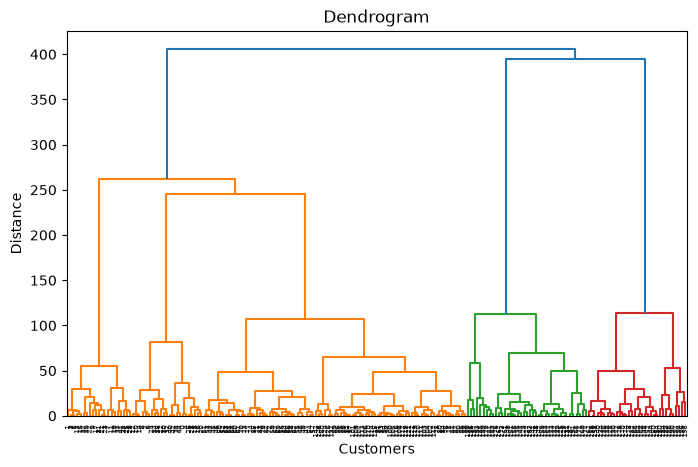

In [8]:
link = linkage(X, method="ward")

plt.figure(figsize=(8,5))
dendrogram(link)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [12]:
model = AgglomerativeClustering(n_clusters=5)

cluster = model.fit_predict(X)

In [15]:
df["New_Cluster"]  = cluster

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   New_Cluster  
0            4  
1            3  
2            4  
3            3  
4            4  


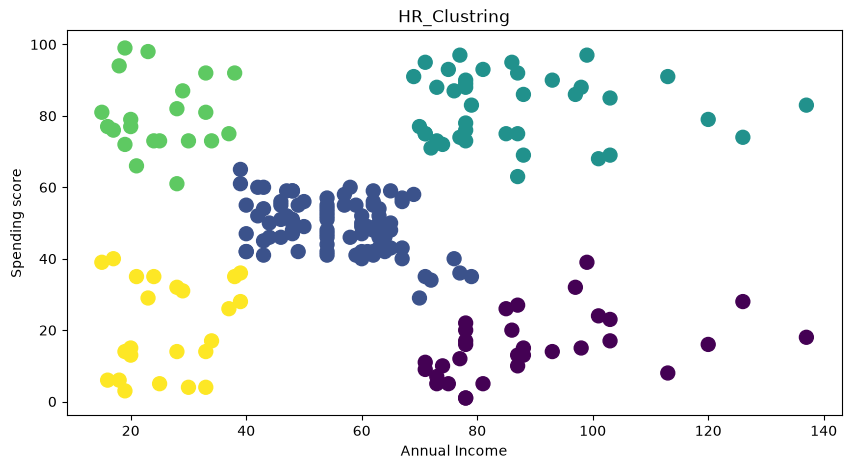

In [16]:
plt.figure(figsize=(10,5))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    s=100,
    c=cluster
)

plt.title("HR_Clustring")
plt.xlabel("Annual Income")
plt.ylabel("Spending score")

plt.show()
